In [1]:
import sys
sys.path.append('..')
from common_helper_functions import *

In [2]:
pops = pd.read_csv('../../../../../../../../s/project/gene_embedding/funcrvp_embeddings/pops_mat_d256.tsv', sep='\t')
pops


,gene_id,0,1,2,3,4,5,6,7,8,...,246,247,248,249,250,251,252,253,254,255
0,ENSG00000186092,-31.893801,27.025212,-14.463574,5.597571,-17.016687,19.347698,21.587237,-10.206741,2.515903,...,-0.223434,-1.305294,0.050859,-0.472052,-0.752233,-0.809979,-0.217098,-0.692682,0.753147,-0.077850
1,ENSG00000235249,-28.775548,26.080314,-15.004325,6.366459,-17.514857,19.262922,23.438640,-10.027345,2.549715,...,-0.064820,-1.446263,0.004087,0.296932,0.151808,-0.033197,-0.515824,0.166302,0.205429,-0.369356
2,ENSG00000185097,-28.934877,25.927851,-15.027671,6.578561,-17.521908,19.367592,23.540710,-9.967279,2.735951,...,0.160623,-1.453526,0.278469,0.577160,0.236100,-0.099776,-0.398618,-0.039934,0.264711,-0.424201
3,ENSG00000187634,-34.299260,1.023238,-4.114987,-8.622390,11.950749,-11.555634,0.067259,-10.630445,2.399708,...,-2.423545,5.545062,-0.760147,-3.951614,-5.568721,-1.263430,-5.207024,-0.757320,1.880727,4.398283
4,ENSG00000188976,60.653929,17.028753,-9.383328,25.768544,8.291885,-4.504261,-5.904711,-0.023688,-2.795766,...,12.276381,-4.053021,1.492080,-2.519403,-7.320323,1.504611,-4.797576,0.327361,-8.205046,1.288697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18378,ENSG00000165724,18.547145,16.351655,-16.462151,15.261519,18.738021,0.625997,5.190327,1.833485,-14.055675,...,-4.115664,0.376620,-1.824978,0.422009,-0.443201,0.788845,0.107122,0.491071,-3.851843,-0.424622
18379,ENSG00000197070,26.197619,25.321029,51.747308,3.744769,-4.441568,16.987834,-19.664660,30.203614,3.736020,...,-6.666760,0.931313,-3.992557,0.804866,4.147680,2.792663,-0.599326,0.746454,1.556210,1.501061
18380,ENSG00000203993,-10.637068,21.352073,-18.331989,6.423512,-12.515978,17.916776,16.948972,-9.912662,6.218952,...,-2.132628,0.181532,0.983204,-0.325371,3.011436,0.756317,-2.191142,2.319716,0.405855,-1.503039
18381,ENSG00000181090,51.509447,-32.963661,-3.575236,52.967038,-2.980225,-6.510085,14.148889,-4.471383,-11.014691,...,-1.190763,-0.355964,-4.518336,4.186252,1.550330,-0.747486,-5.388450,4.146784,4.583694,3.341319


In [3]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [4]:
NCG_Known_Genes = emogi_predictions[['ID', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pops.merge(NCG_Known_Genes, left_on="gene_id" ,right_on='ID', how='inner').drop(columns=['ID'])
merged.set_index('gene_id', inplace=True)
merged

,0,1,2,3,4,5,6,7,8,9,...,250,251,252,253,254,255,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000187634,-34.299260,1.023238,-4.114987,-8.622390,11.950749,-11.555634,0.067259,-10.630445,2.399708,-7.487120,...,-5.568721,-1.263430,-5.207024,-0.757320,1.880727,4.398283,False,False,False,False
ENSG00000188976,60.653929,17.028753,-9.383328,25.768544,8.291885,-4.504261,-5.904711,-0.023688,-2.795766,-9.243552,...,-7.320323,1.504611,-4.797576,0.327361,-8.205046,1.288697,False,False,False,False
ENSG00000187961,-10.688552,-1.783684,-9.703066,11.503596,-5.549109,7.563198,2.399201,-5.812081,1.871219,-1.819183,...,1.699311,-2.313166,-2.539367,-0.185166,0.435921,-0.457364,False,False,False,False
ENSG00000188290,-6.896784,-5.456310,7.146072,-21.817782,-5.106021,8.505768,19.040240,6.512249,-11.567206,25.950848,...,-0.002212,-4.579013,3.224163,-4.374403,-4.814516,-2.646497,False,False,False,False
ENSG00000187608,14.485571,16.575439,85.739793,-45.207595,-17.631146,-14.618216,27.073855,29.655368,55.507390,31.947371,...,-10.191998,-4.709536,-8.669530,-4.912305,6.924740,-11.697215,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000165802,-0.384439,-23.852488,-2.909058,2.137147,-14.700448,8.364768,-9.543997,-10.001479,0.968364,10.488670,...,-0.265873,0.287522,2.837451,-3.599753,7.036098,0.982238,False,False,False,False
ENSG00000182154,90.497335,35.904505,-17.409121,-41.340009,11.133435,27.096046,-40.443438,0.078180,12.955590,-5.548745,...,1.855152,-5.603200,-2.938757,-1.673867,2.686296,0.982387,False,False,False,False
ENSG00000165724,18.547145,16.351655,-16.462151,15.261519,18.738021,0.625997,5.190327,1.833485,-14.055675,-13.946600,...,-0.443201,0.788845,0.107122,0.491071,-3.851843,-0.424622,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [5]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    11753
True       593
Name: count, dtype: int64

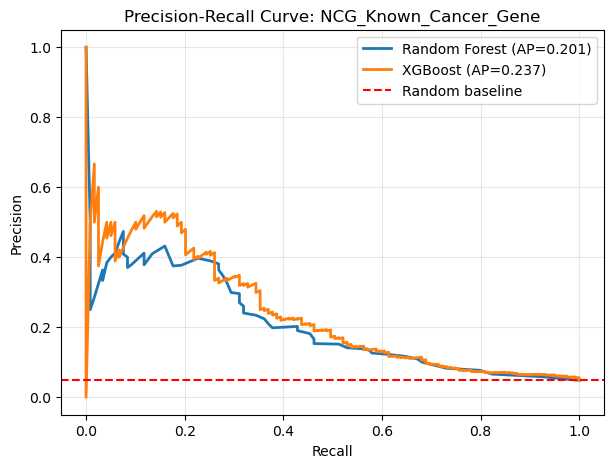

Random Forest - auPRC: 0.201
XGBoost - auPRC: 0.237



In [6]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'Bailey_et_al_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [7]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    11193
True      1153
Name: count, dtype: int64

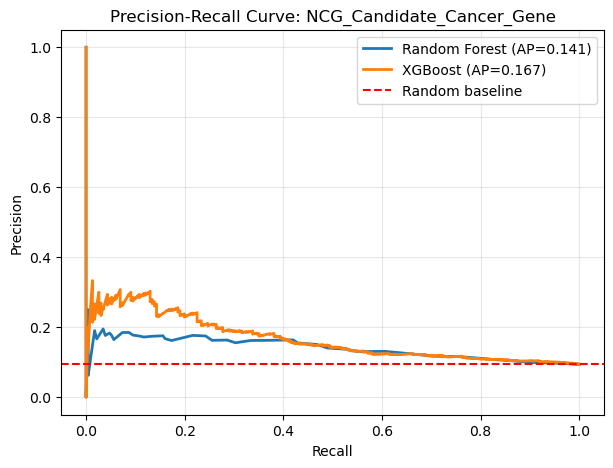

Random Forest - auPRC: 0.141
XGBoost - auPRC: 0.167



In [8]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [9]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    11873
True       473
Name: count, dtype: int64

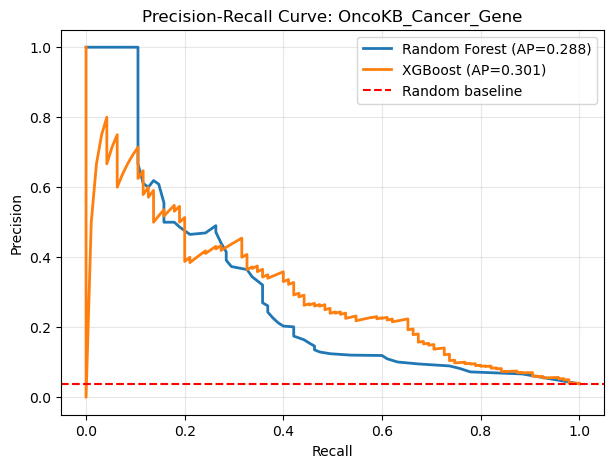

Random Forest - auPRC: 0.288
XGBoost - auPRC: 0.301



In [10]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [11]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    12103
True       243
Name: count, dtype: int64

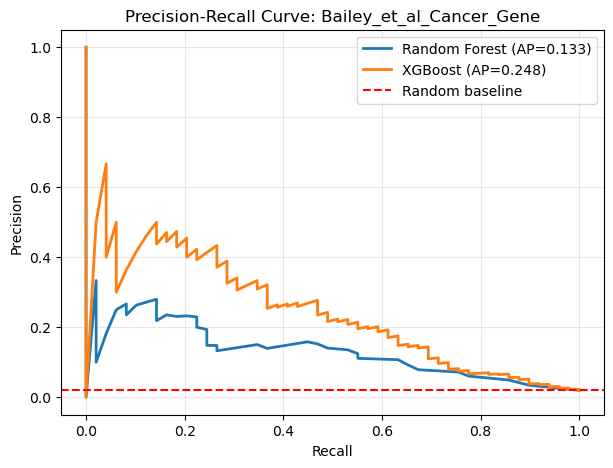

Random Forest - auPRC: 0.133
XGBoost - auPRC: 0.248



In [12]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'Bailey_et_al_Cancer_Gene')